In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/ESP_zonodo/") 
from functions import tangential_velocity, doppio_pipeliner 


In [2]:
width=500
x = np.linspace(-width // 2, width // 2, 101)
y = np.linspace(-width // 2, width // 2, 101)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1, .4, 1
Omega = 0.03
Rc = 85.0 

# rescale Q to have unit determinant
Q = np.array([[Q11, Q12], [Q12, Q22]])
Q = Q / np.sqrt(np.linalg.det(Q))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||

u =  - Omega * (q12*dx + q22*dy) * np.exp( - rho2 / Rc**2 )
v =  + Omega * (q11*dx + q12*dy) * np.exp( - rho2 / Rc**2 ) 
w = Omega*(q11 + q22)


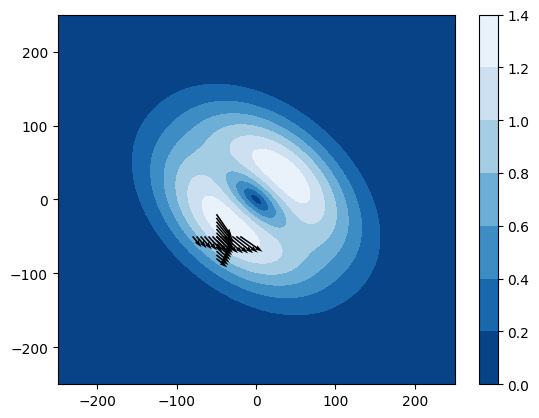

In [33]:
nxc, nyc = -50, -50
x1, y1, u1, v1, x2, y2, u2, v2 = doppio_pipeliner(nxc, nyc, u, v, X, Y, r=30)

plt.contourf(X, Y, np.hypot(u,v), cmap='Blues_r')
plt.colorbar()
plt.quiver(x1, y1, u1, v1, width=.004)
plt.quiver(x2, y2, u2, v2, width=.004)


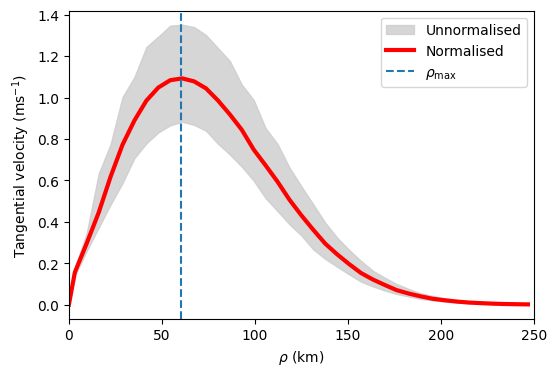

In [30]:
rho_bins = np.linspace(0, 250, 40)
rho_centres = 0.5 * (rho_bins[:-1] + rho_bins[1:])

vt_min = np.full(len(rho_centres), np.nan)
vt_max = np.full(len(rho_centres), np.nan)
vt_norm_med = np.full(len(rho_centres), np.nan)

for i in range(len(rho_bins) - 1):
    m = (rho >= rho_bins[i]) & (rho < rho_bins[i+1])

    if m.sum():
        vt_min[i] = np.nanmin(vt[m])
        vt_max[i] = np.nanmax(vt[m])
        vt_norm_med[i] = np.nanmedian(vt_norm[m])

# prepend origin
rho_plot = np.r_[0, rho_centres]
vt_min_plot = np.r_[0, vt_min]
vt_max_plot = np.r_[0, vt_max]
vt_norm_plot = np.r_[0, vt_norm_med]

fig, ax = plt.subplots(figsize=(6, 4))

ax.fill_between(
    rho_plot,
    vt_min_plot,
    vt_max_plot,
    color='0.8',
    alpha=0.8,
    label=r'Unnormalised'
)

ax.plot(
    rho_plot,
    vt_norm_plot,
    'r',
    lw=3,
    label=r'Normalised'
)

# rho_theo = np.linspace(0, 250, 500)
# vt_theo = Omega * rho_theo * np.exp(-rho_theo**2 / Rc**2)

# ax.plot(
#     rho_theo,
#     vt_theo,
#     'g',
#     lw=2,
#     label='Theory'
# )

ax.axvline(Rc/np.sqrt(2), ls='--', label=r'$\rho_\max$')
ax.set_xlim(0, 250)
ax.set_xlabel(r'$\rho$ (km)')
ax.set_ylabel(r'Tangential velocity (ms$^{-1}$)')
ax.legend()

plt.show()